# HW10-11. Компьютерное зрение в PyTorch. CNN, аугментации, transfer learning на ResNet. Детекция или сегментация, корректная визуализация и базовая валидация.

### 2.4.1. Импорты, seed и устройство

In [1]:
# Импортировать библиотеки: `torch`, `torchvision`, `numpy`, `matplotlib` (и всё, что нужно по делу).
import random
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import time
import torch.optim as optim
import torchvision.models as models
import json
import scipy.ndimage as ndimage
from PIL import Image
import csv

In [2]:
# Зафиксировать seed (минимум `torch.manual_seed`, желательно также `numpy`).
SEED = 42
BATCH_SIZE = 64
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# Определить устройство (`cuda` при наличии, иначе `cpu`) и убедиться, что и модель, и батчи переводятся на один device.
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
Device: cpu


### 2.4.2. Данные и DataLoader

In [4]:
# Подготовить transforms для части A:
# - базовый transform для CNN
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])
# - transform с аугментациями;
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])
# - preprocessing для ResNet с pretrained weights.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
resize = 224
resnet_train_transform = transforms.Compose([
    transforms.Resize(resize + 32),
    transforms.RandomResizedCrop(resize, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
resnet_eval_transform = transforms.Compose([
    transforms.Resize(resize + 32),
    transforms.CenterCrop(resize),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Загрузить выбранный классификационный датасет для части A.
ds_train_full_base = datasets.STL10(root="./data", split='train', download=True, transform=base_transform)
ds_train_full_aug = datasets.STL10(root="./data", split='train', download=True, transform=aug_transform)
ds_train_full_resnet = datasets.STL10(root="./data", split='train', download=True, transform=resnet_train_transform)
ds_train_full_resnet_eval = datasets.STL10(root="./data", split='train', download=True, transform=resnet_eval_transform)
ds_test = datasets.STL10(root="./data", split='test', download=True, transform=resnet_eval_transform)

n_total = len(ds_train_full_base)
n_val = int(n_total * 0.2)
indices = list(range(n_total))
random.Random(SEED).shuffle(indices)
train_idx, val_idx = indices[n_val:], indices[:n_val]

ds_train_base = Subset(ds_train_full_base, train_idx)
ds_val_base = Subset(ds_train_full_base, val_idx)
ds_train_aug = Subset(ds_train_full_aug, train_idx)
ds_val_aug = Subset(ds_train_full_aug, val_idx)

ds_train_resnet = Subset(ds_train_full_resnet, train_idx)
ds_val_resnet = Subset(ds_train_full_resnet_eval, val_idx)

# Создать `DataLoader` для train/val/test в части A.
test_loader_cnn = DataLoader(
    datasets.STL10(root="./data", split='test', download=True, transform=base_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)
test_loader_resnet = DataLoader(
    datasets.STL10(root="./data", split='test', download=True, transform=resnet_eval_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)
train_loader_base = DataLoader(ds_train_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader_base   = DataLoader(ds_val_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
train_loader_aug  = DataLoader(ds_train_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader_aug    = DataLoader(ds_val_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
train_loader_resnet = DataLoader(ds_train_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader_resnet   = DataLoader(ds_val_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Для C2: тренировочный датасет с аугментациями, валидационный – без аугментаций
ds_train_c2 = Subset(ds_train_full_aug, train_idx)
ds_val_c2   = Subset(ds_train_full_base, val_idx)

train_loader_c2 = DataLoader(ds_train_c2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader_c2   = DataLoader(ds_val_c2,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Загрузить выбранный датасет для части B.
seg_image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

def mask_transform(mask):
    mask = mask.resize((224, 224), Image.NEAREST)
    mask = torch.tensor(np.array(mask), dtype=torch.long)
    return mask

class PetSegDataset(torch.utils.data.Dataset):
    def __init__(self, root, split='trainval', transform=None, target_transform=None):
        self.dataset = datasets.OxfordIIITPet(root=root, split=split, target_types=('segmentation', 'binary-category'), download=True)
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, (mask, species) = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        if self.target_transform:
            mask = self.target_transform(mask)
        binary_mask = (mask == 1).long()
        species = torch.tensor(species, dtype=torch.long)
        return img, binary_mask, species

train_dataset_seg = PetSegDataset("./data", split='trainval', transform=seg_image_transform, target_transform=mask_transform)
val_dataset_seg   = PetSegDataset("./data", split='test',     transform=seg_image_transform, target_transform=mask_transform)

train_loader_seg = DataLoader(train_dataset_seg, batch_size=8, shuffle=True, num_workers=0)
val_loader_seg = DataLoader(val_dataset_seg, batch_size=8, shuffle=False, num_workers=0)

# Показать sanity-check и примеры изображений для обеих частей.
def denorm_stl10(x):
    mean = torch.tensor(STL10_MEAN).view(3,1,1)
    std = torch.tensor(STL10_STD).view(3,1,1)
    return x * std + mean

def show_images(loader, n=10):
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()
    plt.figure(figsize=(14,2))
    for i in range(n):
        plt.subplot(1,n,i+1)
        img = denorm_stl10(x[i]).clamp(0,1).permute(1,2,0).numpy()
        plt.imshow(img)
        plt.title(f"{y[i].item()}")
        plt.axis('off')
    plt.show()

def show_seg_examples(dataset, n=3):
    fig, axes = plt.subplots(n, 2, figsize=(6, 3*n))
    for i in range(n):
        img, mask, species = dataset[i]
        img_np = img.permute(1,2,0).numpy()
        img_np = img_np * np.array(IMAGENET_STD).reshape(1,1,3) + np.array(IMAGENET_MEAN).reshape(1,1,3)
        img_np = np.clip(img_np, 0, 1)
        axes[i,0].imshow(img_np)
        axes[i,0].set_title(f"Image (species: {'cat' if species == 0 else 'dog'})")
        axes[i,0].axis('off')
        axes[i,1].imshow(mask.numpy(), cmap='gray')
        axes[i,1].set_title('Ground truth mask')
        axes[i,1].axis('off')
    plt.tight_layout()
    plt.show()

c:\Users\Андрей\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


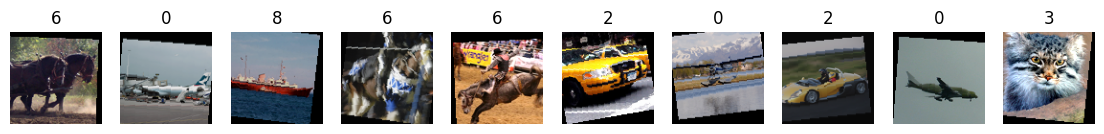

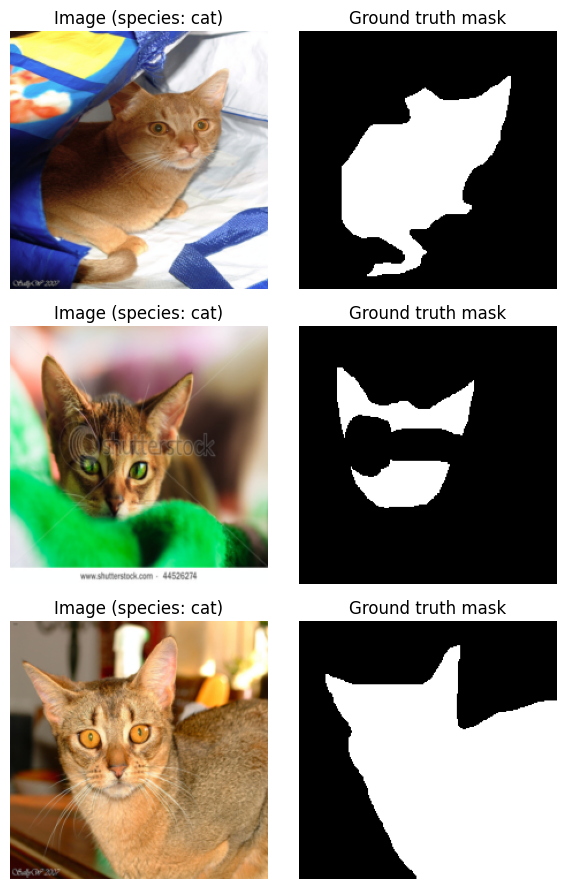

Base loader: x.shape = torch.Size([64, 3, 96, 96]) y.shape = torch.Size([64])
Aug loader: x.shape = torch.Size([64, 3, 96, 96]) y.shape = torch.Size([64])
ResNet loader: x.shape = torch.Size([64, 3, 224, 224]) y.shape = torch.Size([64])


In [5]:
# sane-check
show_images(train_loader_aug, n=10)
show_seg_examples(train_dataset_seg, n=3)

x, y = next(iter(train_loader_base))
print("Base loader: x.shape =", x.shape, "y.shape =", y.shape)
x, y = next(iter(train_loader_aug))
print("Aug loader: x.shape =", x.shape, "y.shape =", y.shape)
x, y = next(iter(train_loader_resnet))
print("ResNet loader: x.shape =", x.shape, "y.shape =", y.shape)

### 2.4.3. Базовые функции обучения и оценки

In [23]:
# Dataset A
class SimpleCNN_STL10(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            return float('nan'), float('nan')
        loss.backward()
        optimizer.step()
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            return float('nan'), float('nan')
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs, verbose=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        dt = time.time() - t0
        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | tr loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f} | {dt:.1f}s")
    return history

# Dataset B
# Загружаем предобученную модель DeepLabV3
weights = models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model_seg = models.segmentation.deeplabv3_resnet50(weights=weights)
model_seg.to(DEVICE)
model_seg.eval()

# Категории COCO+VOC
categories = weights.meta['categories']
print("Number of classes:", len(categories))
CAT_IDX = categories.index('cat')
DOG_IDX = categories.index('dog')
print(f"Cat index: {CAT_IDX}, Dog index: {DOG_IDX}")

# Функция предсказания
def predict_segmentation(img_batch):
    with torch.no_grad():
        img_batch = img_batch.to(DEVICE)
        output = model_seg(img_batch)['out']
        pred_classes = output.argmax(dim=1).cpu()
    return pred_classes

# Функция расчёта метрик
def compute_metrics(pred_mask, gt_mask, species):
    fg_idx = CAT_IDX if species == 0 else DOG_IDX
    pred_binary = (pred_mask == fg_idx).long()
    inter = (pred_binary & gt_mask).sum().item()
    union = (pred_binary | gt_mask).sum().item()
    iou = inter / (union + 1e-9)
    tp = (pred_binary & gt_mask).sum().item()
    fp = (pred_binary & ~gt_mask).sum().item()
    fn = (~pred_binary & gt_mask).sum().item()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    return iou, precision, recall

# Базовый режим V1 (без постобработки)
def evaluate_v1(loader):
    ious, precisions, recalls = [], [], []
    for img, mask, species in loader:
        img = img.to(DEVICE)
        pred_batch = predict_segmentation(img)
        for i in range(img.size(0)):
            iou, prec, rec = compute_metrics(pred_batch[i], mask[i], species[i])
            ious.append(iou)
            precisions.append(prec)
            recalls.append(rec)
    return {'mean_iou': np.mean(ious), 'precision': np.mean(precisions), 'recall': np.mean(recalls)}

# Альтернативный режим V2: удаление маленьких компонент связности
def remove_small_components(mask, min_size=30):
    if mask.sum() == 0:
        return mask
    mask_np = mask.numpy().astype(np.uint8)
    labeled, num = ndimage.label(mask_np)
    sizes = ndimage.sum(mask_np, labeled, range(1, num+1))
    keep = sizes >= min_size
    new_mask = np.zeros_like(mask_np)
    for i, keep_flag in enumerate(keep, start=1):
        if keep_flag:
            new_mask[labeled == i] = 1
    return torch.tensor(new_mask, dtype=torch.long)

def evaluate_v2(loader, min_size=30):
    ious, precisions, recalls = [], [], []
    total_examples = 0
    masks_changed = 0
    total_removed_pixels = 0

    for img, mask, species in loader:
        img = img.to(DEVICE)
        pred_batch = predict_segmentation(img)
        for i in range(img.size(0)):
            total_examples += 1
            fg_idx = CAT_IDX if species[i] == 0 else DOG_IDX
            pred_binary = (pred_batch[i] == fg_idx).long()
            before_pixels = pred_binary.sum().item()
            pred_binary_cleaned = remove_small_components(pred_binary, min_size=min_size)
            after_pixels = pred_binary_cleaned.sum().item()
            if before_pixels != after_pixels:
                masks_changed += 1
                total_removed_pixels += (before_pixels - after_pixels)

            pred_class_cleaned = torch.zeros_like(pred_binary_cleaned)
            pred_class_cleaned[pred_binary_cleaned == 1] = fg_idx

            iou, prec, rec = compute_metrics(pred_class_cleaned, mask[i], species[i])
            ious.append(iou)
            precisions.append(prec)
            recalls.append(rec)

    print(f"Total examples: {total_examples}")
    print(f"Masks changed: {masks_changed} ({100 * masks_changed / total_examples:.2f}%)")
    if masks_changed > 0:
        print(f"Average removed pixels per changed mask: {total_removed_pixels / masks_changed:.1f}")
    else:
        print("No masks were changed.")
    return {
        'mean_iou': np.mean(ious),
        'precision': np.mean(precisions),
        'recall': np.mean(recalls)
    }

def visualize_segmentation(dataset, indices, postprocess_func=None):
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        img, mask, species = dataset[idx]
        pred_class = predict_segmentation(img.unsqueeze(0)).squeeze(0)
        fg_idx = CAT_IDX if species == 0 else DOG_IDX
        pred_binary = (pred_class == fg_idx).long()
        if postprocess_func:
            pred_binary = postprocess_func(pred_binary)
        
        img_np = img.permute(1, 2, 0).numpy()
        img_np = img_np * np.array(IMAGENET_STD).reshape(1, 1, 3) + np.array(IMAGENET_MEAN).reshape(1, 1, 3)
        img_np = np.clip(img_np, 0, 1)
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"Image (species: {'cat' if species == 0 else 'dog'})")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask.numpy(), cmap='gray')
        axes[i, 1].set_title('GT mask')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_binary.numpy(), cmap='gray')
        axes[i, 2].set_title('Pred mask')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    return fig

Number of classes: 21
Cat index: 8, Dog index: 12


## 3. Эксперименты

### Часть A (S10): классификация, аугментации и transfer learning

In [7]:
criterion = nn.CrossEntropyLoss()
experiments = []

# C1 (simple-cnn-base): простая CNN без аугментаций
print("C1")
model_c1 = SimpleCNN_STL10().to(DEVICE)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=1e-3)
hist_c1 = fit(model_c1, train_loader_base, val_loader_base, optimizer_c1, criterion, epochs=12)
best_val_c1 = max(hist_c1['val_acc'])
experiments.append(('C1', 'simple-cnn-base', best_val_c1, hist_c1, model_c1))

C1
Epoch 01/12 | tr loss 1.9849 acc 0.243 | val loss 1.6271 acc 0.369 | 40.1s
Epoch 02/12 | tr loss 1.5891 acc 0.388 | val loss 1.5066 acc 0.417 | 39.8s
Epoch 03/12 | tr loss 1.4499 acc 0.437 | val loss 1.3741 acc 0.458 | 39.1s
Epoch 04/12 | tr loss 1.2894 acc 0.517 | val loss 1.2940 acc 0.515 | 38.7s
Epoch 05/12 | tr loss 1.1771 acc 0.551 | val loss 1.2890 acc 0.519 | 39.2s
Epoch 06/12 | tr loss 1.0197 acc 0.615 | val loss 1.1385 acc 0.564 | 38.5s
Epoch 07/12 | tr loss 0.9058 acc 0.666 | val loss 1.1048 acc 0.582 | 39.8s
Epoch 08/12 | tr loss 0.8035 acc 0.705 | val loss 1.0757 acc 0.602 | 38.6s
Epoch 09/12 | tr loss 0.6476 acc 0.771 | val loss 1.1564 acc 0.590 | 38.9s
Epoch 10/12 | tr loss 0.5379 acc 0.815 | val loss 1.1672 acc 0.600 | 38.7s
Epoch 11/12 | tr loss 0.4160 acc 0.859 | val loss 1.2034 acc 0.612 | 39.6s
Epoch 12/12 | tr loss 0.3388 acc 0.884 | val loss 1.4601 acc 0.586 | 40.6s


In [8]:
# C2 (simple-cnn-aug): та же CNN, но с разумными аугментациями.
print("C2")
model_c2 = SimpleCNN_STL10().to(DEVICE)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=1e-3)
hist_c2 = fit(model_c2, train_loader_c2, val_loader_c2, optimizer_c2, criterion, epochs=12)
best_val_c2 = max(hist_c2['val_acc'])
experiments.append(('C2', 'simple-cnn-aug', best_val_c2, hist_c2, model_c2))

C2
Epoch 01/12 | tr loss 2.0687 acc 0.230 | val loss 1.8168 acc 0.276 | 48.3s
Epoch 02/12 | tr loss 1.7260 acc 0.341 | val loss 1.5544 acc 0.422 | 47.0s
Epoch 03/12 | tr loss 1.5843 acc 0.390 | val loss 1.5063 acc 0.408 | 47.0s
Epoch 04/12 | tr loss 1.4933 acc 0.425 | val loss 1.3455 acc 0.497 | 46.9s
Epoch 05/12 | tr loss 1.4265 acc 0.459 | val loss 1.3271 acc 0.501 | 47.2s
Epoch 06/12 | tr loss 1.3635 acc 0.490 | val loss 1.2336 acc 0.549 | 46.8s
Epoch 07/12 | tr loss 1.2652 acc 0.520 | val loss 1.1905 acc 0.558 | 46.5s
Epoch 08/12 | tr loss 1.2423 acc 0.537 | val loss 1.1529 acc 0.579 | 49.7s
Epoch 09/12 | tr loss 1.1738 acc 0.561 | val loss 1.1536 acc 0.569 | 47.4s
Epoch 10/12 | tr loss 1.1473 acc 0.576 | val loss 1.1569 acc 0.595 | 47.7s
Epoch 11/12 | tr loss 1.1309 acc 0.584 | val loss 1.0704 acc 0.619 | 48.1s
Epoch 12/12 | tr loss 1.0620 acc 0.606 | val loss 1.1278 acc 0.595 | 50.3s


In [9]:
# C3 (resnet18-head-only): `ResNet18` с pretrained weights; backbone заморожен, обучается только классификационная голова.
print("C3")
def get_resnet18_head(num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model_c3 = get_resnet18_head().to(DEVICE)
optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=1e-3)
hist_c3 = fit(model_c3, train_loader_resnet, val_loader_resnet, optimizer_c3, criterion, epochs=12)
best_val_c3 = max(hist_c3['val_acc'])
experiments.append(('C3', 'resnet18-head-only', best_val_c3, hist_c3, model_c3))

C3
Epoch 01/12 | tr loss 1.0988 acc 0.715 | val loss 0.4354 acc 0.920 | 146.8s
Epoch 02/12 | tr loss 0.3942 acc 0.913 | val loss 0.2834 acc 0.941 | 146.4s
Epoch 03/12 | tr loss 0.2961 acc 0.930 | val loss 0.2317 acc 0.940 | 145.7s
Epoch 04/12 | tr loss 0.2482 acc 0.935 | val loss 0.2221 acc 0.943 | 145.8s
Epoch 05/12 | tr loss 0.2210 acc 0.938 | val loss 0.1916 acc 0.955 | 146.1s
Epoch 06/12 | tr loss 0.2088 acc 0.939 | val loss 0.1793 acc 0.950 | 145.8s
Epoch 07/12 | tr loss 0.1814 acc 0.949 | val loss 0.1793 acc 0.954 | 146.7s
Epoch 08/12 | tr loss 0.1765 acc 0.946 | val loss 0.1757 acc 0.949 | 146.3s
Epoch 09/12 | tr loss 0.1825 acc 0.946 | val loss 0.1694 acc 0.945 | 145.4s
Epoch 10/12 | tr loss 0.1647 acc 0.949 | val loss 0.1714 acc 0.946 | 151.1s
Epoch 11/12 | tr loss 0.1537 acc 0.952 | val loss 0.1729 acc 0.948 | 150.4s
Epoch 12/12 | tr loss 0.1475 acc 0.957 | val loss 0.1736 acc 0.950 | 150.2s


In [10]:
# C4 (resnet18-finetune): `ResNet18` с pretrained weights; частичное fine-tune (например, `layer4 + fc`, либо другой близкий по смыслу вариант).
print("C4")
model_c4 = get_resnet18_head().to(DEVICE)
for param in model_c4.layer4.parameters():
    param.requires_grad = True
optimizer_c4 = optim.Adam([
    {'params': model_c4.layer4.parameters(), 'lr': 1e-4},
    {'params': model_c4.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)
hist_c4 = fit(model_c4, train_loader_resnet, val_loader_resnet, optimizer_c4, criterion, epochs=12)
best_val_c4 = max(hist_c4['val_acc'])
experiments.append(('C4', 'resnet18-finetune', best_val_c4, hist_c4, model_c4))

C4
Epoch 01/12 | tr loss 0.5453 acc 0.838 | val loss 0.1791 acc 0.942 | 207.4s
Epoch 02/12 | tr loss 0.1403 acc 0.957 | val loss 0.1601 acc 0.951 | 206.8s
Epoch 03/12 | tr loss 0.0751 acc 0.979 | val loss 0.1863 acc 0.942 | 206.1s
Epoch 04/12 | tr loss 0.0532 acc 0.985 | val loss 0.1623 acc 0.953 | 207.4s
Epoch 05/12 | tr loss 0.0266 acc 0.995 | val loss 0.1672 acc 0.951 | 207.5s
Epoch 06/12 | tr loss 0.0282 acc 0.992 | val loss 0.1655 acc 0.952 | 207.3s
Epoch 07/12 | tr loss 0.0205 acc 0.996 | val loss 0.1533 acc 0.955 | 207.1s
Epoch 08/12 | tr loss 0.0211 acc 0.994 | val loss 0.1896 acc 0.948 | 206.2s
Epoch 09/12 | tr loss 0.0146 acc 0.996 | val loss 0.1694 acc 0.957 | 208.2s
Epoch 10/12 | tr loss 0.0112 acc 0.997 | val loss 0.1876 acc 0.954 | 206.8s
Epoch 11/12 | tr loss 0.0104 acc 0.997 | val loss 0.2025 acc 0.948 | 206.7s
Epoch 12/12 | tr loss 0.0116 acc 0.997 | val loss 0.1889 acc 0.944 | 206.5s


Лучшая модель: resnet18-finetune (val acc = 0.9570)
Test accuracy лучшей модели: 0.9463


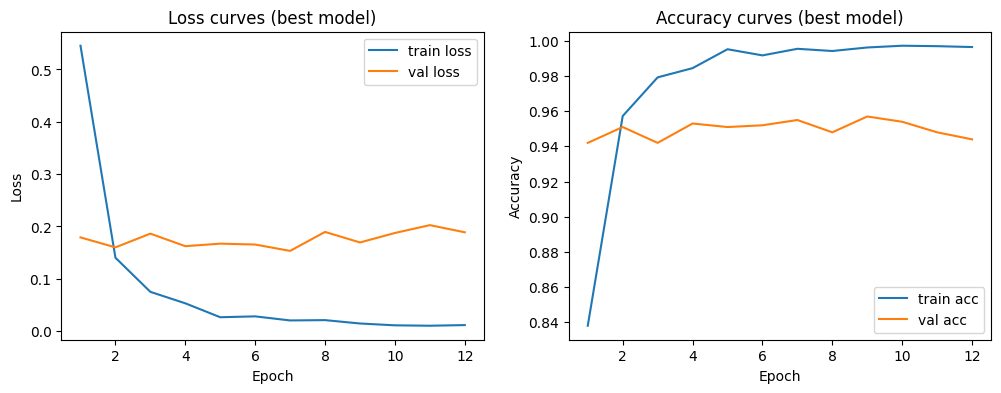

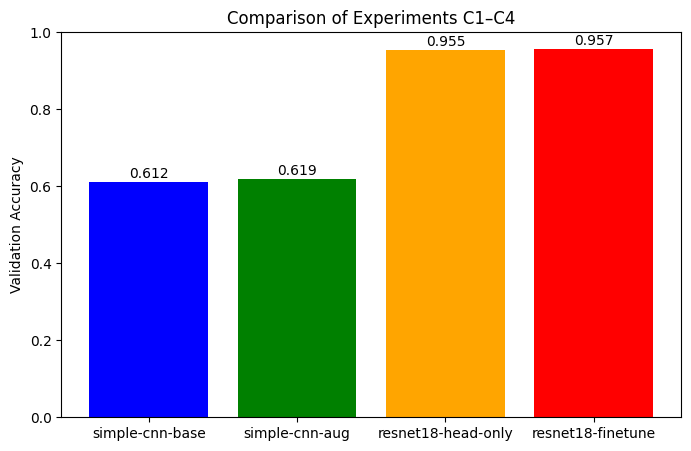

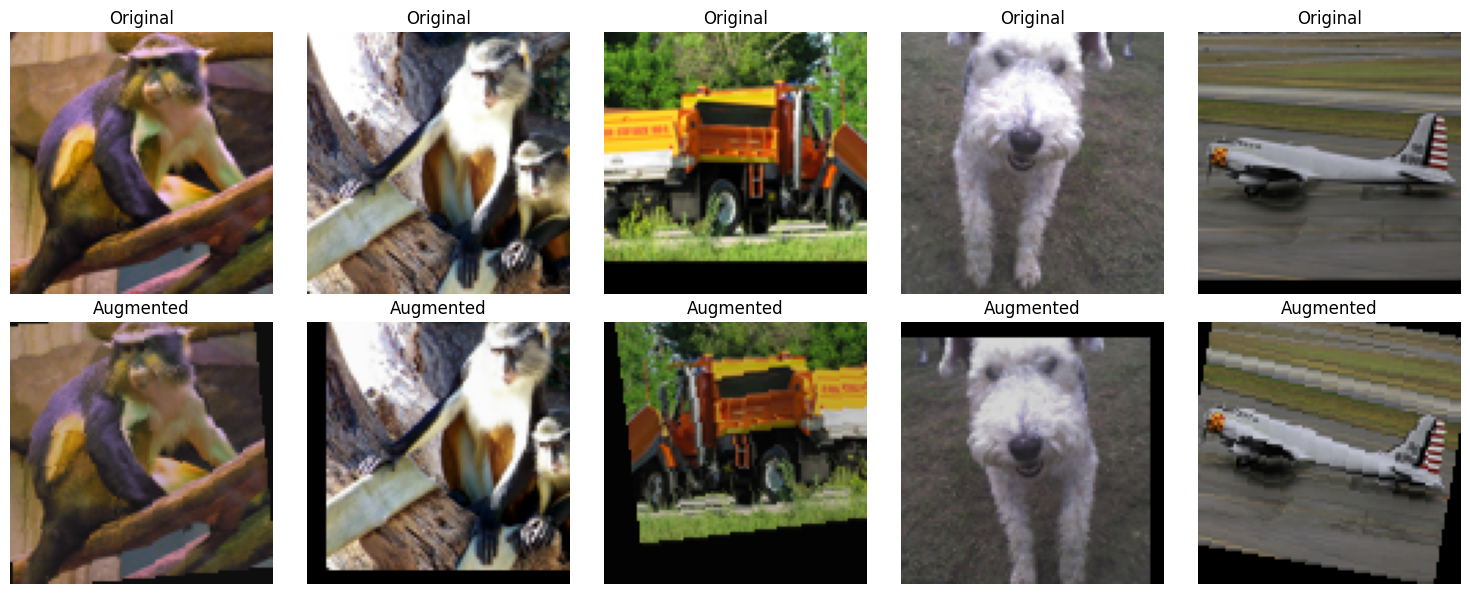

In [11]:
# Выбор лучшей модели и визуализация для части А
best_exp = max(experiments, key=lambda x: x[2])
best_id, best_name, best_val, best_hist, best_model = best_exp
print(f"Лучшая модель: {best_name} (val acc = {best_val:.4f})")

if 'simple' in best_name:
    transform_desc = "base_transform" if best_name == 'simple-cnn-base' else "aug_transform" # C1 или C2
else:
    transform_desc = "resnet_train_transform (with resize/crop/normalize)" # C3 или C4
torch.save(best_model.state_dict(), 'artifacts/best_classifier.pt')
config = {
    'dataset': 'STL10',
    'architecture': best_name,
    'seed': SEED,
    'best_val_accuracy': best_val,
    'epochs': 12,
    'batch_size': BATCH_SIZE,
    'optimizer': 'Adam',
    'lr': '1e-3' if 'simple' in best_name else '1e-3/1e-4 for C4',
    'transforms': transform_desc
}
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=2)

@torch.no_grad()
def test_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total += y.size(0)
    return correct / total

if 'simple' in best_name:
    test_acc = test_accuracy(best_model, test_loader_cnn) # C1 или C2
else:
    test_acc = test_accuracy(best_model, test_loader_resnet) # C3 или C4 (resnet)
print(f"Test accuracy лучшей модели: {test_acc:.4f}")
# 1. Графики обучения для лучшей модели
epochs = range(1, len(best_hist['train_loss'])+1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, best_hist['train_loss'], label='train loss')
plt.plot(epochs, best_hist['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves (best model)')
plt.subplot(1,2,2)
plt.plot(epochs, best_hist['train_acc'], label='train acc')
plt.plot(epochs, best_hist['val_acc'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy curves (best model)')
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150)
plt.show()

# Сравнение C1–C4 (bar plot)
exp_names = [e[1] for e in experiments]
val_accs = [e[2] for e in experiments]
plt.figure(figsize=(8,5))
bars = plt.bar(exp_names, val_accs, color=['blue','green','orange','red'])
plt.ylim(0,1)
plt.ylabel('Validation Accuracy')
plt.title('Comparison of Experiments C1–C4')
for bar, acc in zip(bars, val_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}', ha='center')
plt.savefig('artifacts/figures/classification_compare.png', dpi=150)
plt.show()

# Визуализация аугментаций
def show_augmentations(dataset_orig, dataset_aug, n=5):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for i in range(n):
        img_orig, _ = dataset_orig[i]
        img_aug, _ = dataset_aug[i]
        axes[0,i].imshow(denorm_stl10(img_orig).permute(1,2,0).clamp(0,1))
        axes[0,i].set_title('Original')
        axes[0,i].axis('off')
        axes[1,i].imshow(denorm_stl10(img_aug).permute(1,2,0).clamp(0,1))
        axes[1,i].set_title('Augmented')
        axes[1,i].axis('off')
    plt.tight_layout()
    plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150)
    plt.show()

show_augmentations(ds_train_base, ds_train_aug, n=5)

### Часть B (S11): сегментация 

In [12]:
metrics_v1 = evaluate_v1(val_loader_seg)
print("V1 (baseline) results:", metrics_v1)

V1 (baseline) results: {'mean_iou': np.float64(0.7053896321731035), 'precision': np.float64(0.7281457139996595), 'recall': np.float64(0.9254109318352065)}


In [25]:
metrics_v2 = evaluate_v2(val_loader_seg, 30)
print("V2 (with component removal) results:", metrics_v2)

Total examples: 3669
Masks changed: 193 (5.26%)
Average removed pixels per changed mask: 16.5
V2 (with component removal) results: {'mean_iou': np.float64(0.7053774261085105), 'precision': np.float64(0.7270793130784555), 'recall': np.float64(0.9253649252578168)}


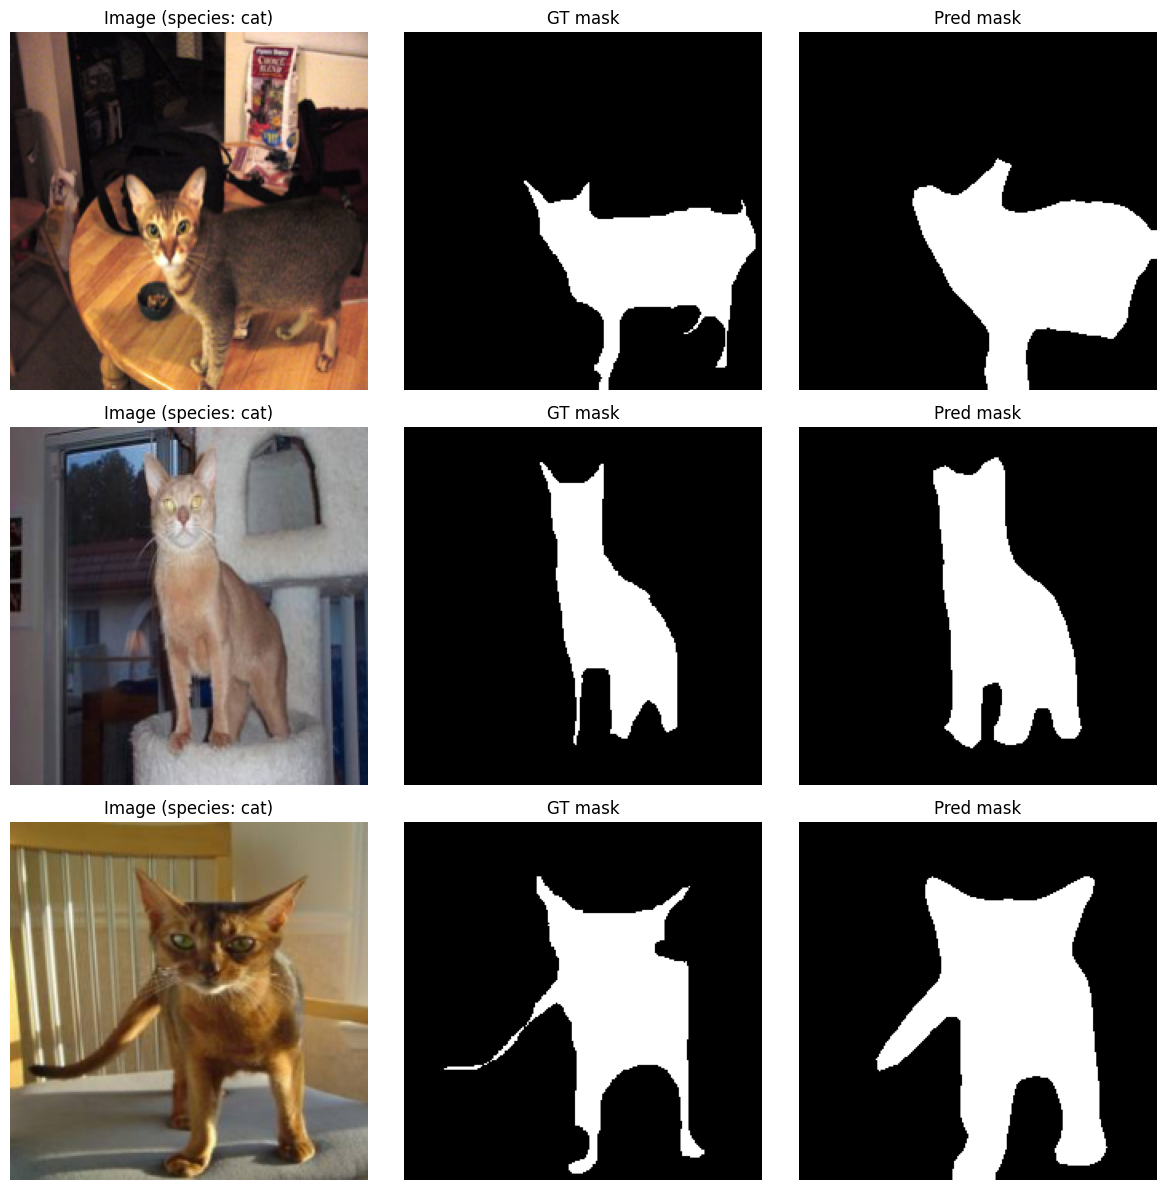

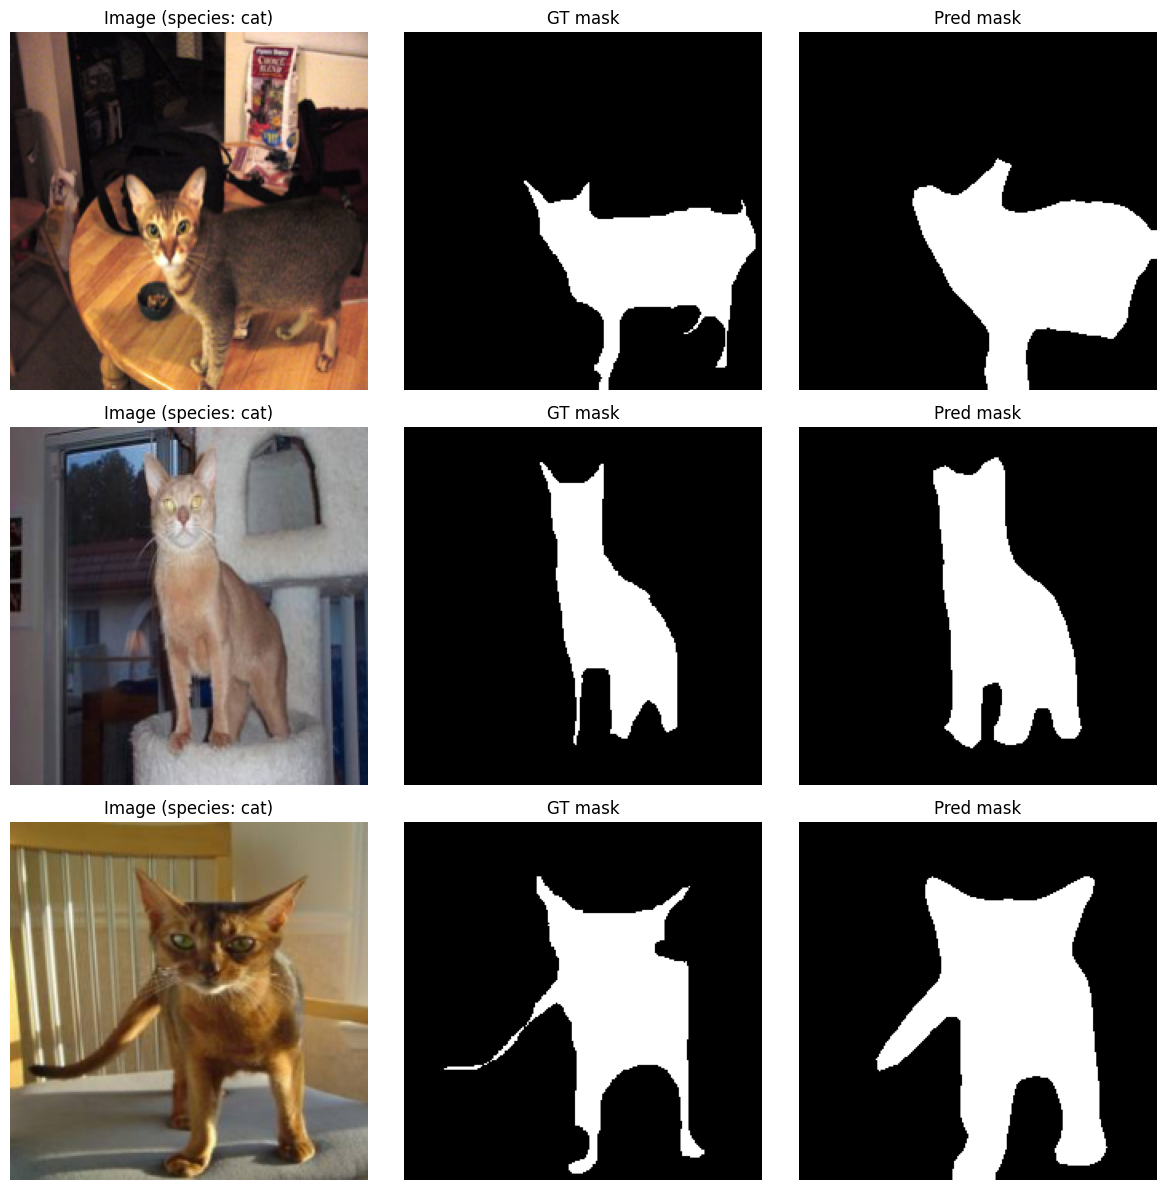

In [26]:
# Визуализация для V1
fig_v1 = visualize_segmentation(val_dataset_seg, indices=range(3), postprocess_func=None)
plt.savefig('artifacts/figures/segmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
# Визуализация для V2 (с удалением маленьких компонент)
fig_v2 = visualize_segmentation(val_dataset_seg, indices=range(3), postprocess_func=lambda x: remove_small_components(x, min_size=20))
plt.savefig('artifacts/figures/segmentation_examples_v2.png', dpi=150, bbox_inches='tight')
plt.show()

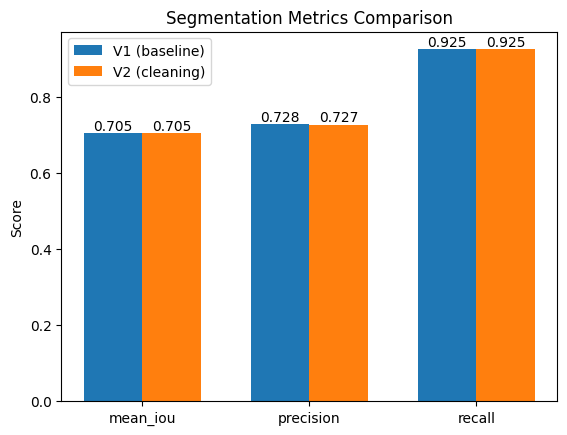

In [27]:
metrics_dict = {'V1': metrics_v1, 'V2': metrics_v2}
metric_names = ['mean_iou', 'precision', 'recall']
x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, [metrics_dict['V1'][m] for m in metric_names], width, label='V1 (baseline)')
bars2 = ax.bar(x + width/2, [metrics_dict['V2'][m] for m in metric_names], width, label='V2 (cleaning)')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()
ax.set_title('Segmentation Metrics Comparison')
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom')
plt.savefig('artifacts/figures/segmentation_metrics.png', dpi=150)
plt.show()

In [28]:
rows = []

# Эксперименты классификации
for exp_id, model_name, val_acc, hist, _ in experiments:
    row = {
        'experiment_id': exp_id,
        'task': 'classification',
        'dataset': 'STL10',
        'seed': SEED,
        'model_summary': model_name,
        'optimizer': 'Adam',
        'lr': '1e-3' if 'simple' in model_name else ('1e-3/1e-4' if 'finetune' in model_name else '1e-3'),
        'epochs_trained': 12,
        'best_val_accuracy': val_acc,
        'test_accuracy': test_acc if exp_id == best_id else '',
        'precision': '',
        'recall': '',
        'mean_iou': '',
        'notes': ''
    }
    rows.append(row)

# Эксперименты сегментации
for exp_id, metrics in [('V1', metrics_v1), ('V2', metrics_v2)]:
    row = {
        'experiment_id': exp_id,
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': SEED,
        'model_summary': 'DeepLabV3_ResNet50_COCO',
        'optimizer': '',
        'lr': '',
        'epochs_trained': '',
        'best_val_accuracy': '',
        'test_accuracy': '',
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'mean_iou': metrics['mean_iou'],
        'notes': 'V2: remove small components (min_size=100)' if exp_id == 'V2' else ''
    }
    rows.append(row)

# Запись в CSV
fieldnames = ['experiment_id', 'task', 'dataset', 'seed', 'model_summary', 'optimizer', 'lr',
              'epochs_trained', 'best_val_accuracy', 'test_accuracy', 'precision', 'recall', 'mean_iou', 'notes']
with open('artifacts/runs.csv', 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)